In [1]:
from node2vec import Node2Vec
import umap.umap_ as umap
import networkx as nx
import pandas as pd

print("OK")

OK


In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from node2vec import Node2Vec
import umap.umap_ as umap

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Read processed data
club_edges = pd.read_csv("club_edges.csv")
club_nodes = pd.read_csv("club_nodes_with_clusters.csv")

print("Edges:", club_edges.shape)
print("Nodes:", club_nodes.shape)

display(club_edges.head())
display(club_nodes.head())

Edges: (31272, 10)
Nodes: (3606, 17)


,source_club,target_club,transfer_count,total_transfer_fee,average_transfer_fee,max_transfer_fee,first_season,last_season,source_country,target_country
0,1. FC Brno,SC Heerenveen,1,0.0,0.0,0.0,2009,2009,Czech Republic,Netherlands
1,1. FC Köln,1.FC Heidenheim 1846,1,600000.0,600000.0,600000.0,2015,2015,Germany,Germany
2,1. FC Köln,1.FC Kaiserslautern,2,500000.0,250000.0,500000.0,2014,2015,Germany,Germany
3,1. FC Köln,1.FC Köln II,3,0.0,0.0,0.0,2014,2015,Germany,Germany
4,1. FC Köln,1.FC Nuremberg,5,800000.0,160000.0,500000.0,2009,2019,Germany,Germany


,club,country,transfers_out,total_fee_out,transfers_in,total_fee_in,total_transfers,total_fee_involved,degree,in_degree,out_degree,weighted_in_degree,weighted_out_degree,weighted_degree,pagerank,louvain_cluster,louvain_cluster_label
0,Wigan Athletic,England,143.0,153050000.0,155.0,81775000.0,298.0,2.348250e+08,144,75,69,155,143,298,0.001938,0,England / Scotland
1,Molde FK,Norway,16.0,17260000.0,8.0,2000000.0,24.0,1.926000e+07,17,6,11,8,16,24,0.000137,0,England / Scotland
2,FC Girondins Bordeaux,France,256.0,471620000.0,272.0,251180000.0,528.0,7.228000e+08,218,99,119,272,256,528,0.002862,1,France / Belgium
3,Newcastle United,England,274.0,567420000.0,293.0,849790000.0,567.0,1.417210e+09,252,128,124,293,274,567,0.003672,0,England / Scotland
4,Manchester United U18,England,15.0,0.0,0.0,0.0,15.0,0.000000e+00,3,0,3,0,15,15,0.000060,0,England / Scotland


In [2]:
G = nx.Graph()

# Add nodes
for _, row in club_nodes.iterrows():
    G.add_node(row["club"])

# Add weighted edges
for _, row in club_edges.iterrows():
    G.add_edge(
        row["source_club"],
        row["target_club"],
        weight=row["transfer_count"]
    )

print("Before removing isolated nodes:")
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

# Remove isolated nodes if any
isolated_nodes = list(nx.isolates(G))
print("Number of isolated nodes:", len(isolated_nodes))

G.remove_nodes_from(isolated_nodes)

print("After removing isolated nodes:")
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Before removing isolated nodes:
Number of nodes: 3606
Number of edges: 22664
Number of isolated nodes: 0
After removing isolated nodes:
Number of nodes: 3606
Number of edges: 22664


In [3]:
node2vec = Node2Vec(
    G,
    dimensions=64,       # 每个俱乐部生成 64 维向量
    walk_length=20,      # 每次随机游走长度
    num_walks=100,       # 每个节点随机游走次数
    workers=1,           # Windows/Jupyter 下 workers=1 最稳
    weight_key="weight",
    seed=42
)

model = node2vec.fit(
    window=10,
    min_count=1,
    batch_words=4
)

print("Node2Vec training finished.")

Computing transition probabilities:   0%|          | 0/3606 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 100/100 [01:48<00:00,  1.09s/it]
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.

Node2Vec training finished.


In [4]:
node2vec = Node2Vec(
    G,
    dimensions=32,
    walk_length=10,
    num_walks=50,
    workers=1,
    weight_key="weight",
    seed=42
)

model = node2vec.fit(
    window=5,
    min_count=1,
    batch_words=4
)

Computing transition probabilities:   0%|          | 0/3606 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 50/50 [00:35<00:00,  1.42it/s]
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [4]:
embeddings = []

for club in G.nodes():
    vector = model.wv[str(club)]
    embeddings.append([club] + list(vector))

embedding_cols = [f"emb_{i}" for i in range(model.vector_size)]

club_embeddings = pd.DataFrame(
    embeddings,
    columns=["club"] + embedding_cols
)

print("Embedding table shape:", club_embeddings.shape)
display(club_embeddings.head())

Embedding table shape: (3606, 65)


,club,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,emb_10,emb_11,emb_12,emb_13,emb_14,emb_15,emb_16,emb_17,emb_18,emb_19,emb_20,emb_21,emb_22,emb_23,emb_24,emb_25,emb_26,emb_27,emb_28,emb_29,emb_30,emb_31,emb_32,emb_33,emb_34,emb_35,emb_36,emb_37,emb_38,emb_39,emb_40,emb_41,emb_42,emb_43,emb_44,emb_45,emb_46,emb_47,emb_48,emb_49,emb_50,emb_51,emb_52,emb_53,emb_54,emb_55,emb_56,emb_57,emb_58,emb_59,emb_60,emb_61,emb_62,emb_63
0,Wigan Athletic,0.207819,-0.344015,0.279859,0.156229,-0.045411,-0.487845,-0.039935,-0.225183,-0.258067,0.442886,-0.335242,-0.289587,-0.309080,0.030012,-0.145182,0.766204,-0.097677,-0.203033,0.326669,0.078999,0.445149,-0.142615,-0.255637,-0.238424,-0.477541,0.063684,-0.477320,-0.084368,0.123490,-0.458236,0.049201,-0.076046,-0.332091,-0.061175,-0.417066,-0.374842,-0.009980,0.081334,0.076987,0.018581,-0.308443,-0.048535,-0.069835,0.177600,-0.102021,0.149509,-0.112408,-0.155636,0.005412,0.101227,0.256740,0.048766,0.048374,-0.062562,-0.256335,-0.412699,-0.094624,0.216321,-0.159803,-0.314538,-0.168391,-0.102748,-0.085512,-0.398543
1,Molde FK,0.271641,-0.394520,-0.137864,-0.545803,-0.495291,0.041681,0.400117,-0.078611,-0.271164,0.112900,0.534392,-0.283264,-0.122349,0.199511,-0.325339,0.601542,-0.216249,0.264764,0.115094,0.188561,0.694366,-0.310768,-0.525203,-0.598347,-0.464653,0.132821,-0.039403,-0.094727,-0.101061,-0.144589,0.072197,-0.202359,0.062951,0.274663,-0.547800,0.427346,0.235945,0.019891,-0.034290,0.014295,0.000720,0.098258,-0.500727,-0.657339,-0.074546,-0.107128,-0.448717,-0.458680,0.402759,0.029947,0.234734,-0.238127,0.021430,-0.065131,-0.122197,-0.066909,-0.104318,-0.154431,-0.603335,0.381556,-0.267843,-0.259407,-0.240139,-0.047494
2,FC Girondins Bordeaux,0.109550,-0.521252,0.171755,-0.211340,0.434227,0.120976,0.117014,-0.276152,-0.000449,0.059469,0.083864,-0.348308,-0.431720,0.263652,0.151497,0.339470,-0.011265,0.332509,0.109288,-0.100029,-0.069781,0.413560,0.004097,-0.489210,0.225077,0.239195,-0.336563,-0.004467,-0.148158,-0.030348,0.050481,0.318421,-0.019112,0.229775,-0.196388,0.103641,0.177026,-0.318482,-0.511239,0.629136,-0.186867,0.310455,-0.009391,-0.209351,-0.310307,0.166129,-0.152992,-0.143375,0.034068,0.204109,0.012255,0.316968,0.003885,-0.176496,0.115815,-0.029173,-0.050479,0.077104,-0.328915,-0.097831,-0.039630,-0.403109,-0.040745,0.273510
3,Newcastle United,0.171613,-0.562764,-0.172617,-0.325131,0.145369,-0.332349,-0.378420,-0.228227,0.249504,0.220915,0.075612,0.172310,-0.222316,0.021543,-0.120138,0.681744,0.030171,-0.298616,0.301177,0.151857,0.524456,-0.336851,-0.003980,-0.178283,-0.053227,0.248243,-0.381970,0.030624,0.100726,-0.062339,0.386581,0.006501,-0.007966,0.108553,-0.290940,0.097573,0.073232,-0.035522,-0.192730,0.143860,0.073515,-0.138488,-0.054071,0.003532,0.029118,0.113458,0.344809,-0.310792,0.296069,0.230114,0.309483,-0.086799,0.187097,-0.347597,0.019344,-0.082328,0.105920,-0.044637,-0.310406,0.082465,-0.296435,-0.090167,0.192061,0.105932
4,Manchester United U18,0.285741,-0.371661,0.538843,-0.775924,-0.245327,-0.574132,0.062754,0.191219,-0.096142,0.141741,0.539119,-0.528633,-0.450010,0.024467,-0.196072,0.241149,-0.274863,-0.171746,0.446198,0.283159,0.292379,0.247056,0.360492,-0.014654,-0.306032,-0.340244,-0.554924,0.082376,-0.161568,-0.266957,-0.227455,0.136583,-0.187151,0.009073,-0.555755,0.150357,0.012276,0.156433,0.131198,-0.352922,0.540441,0.586492,-0.245923,-0.336812,0.234123,0.129380,-0.308429,-0.391119,0.234644,0.024412,-0.065113,0.304664,0.375218,-0.296631,-0.497316,-0.050014,-0.076237,0.234680,-0.065927,0.487049,-0.109036,0.228740,0.399952,-0.354270


In [6]:
from sklearn.decomposition import PCA

In [7]:
X = club_embeddings[embedding_cols].values

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

club_embeddings["embed_x"] = X_pca[:, 0]
club_embeddings["embed_y"] = X_pca[:, 1]

print("PCA explained variance ratio:", pca.explained_variance_ratio_)
display(club_embeddings.head())

PCA explained variance ratio: [0.08300097 0.07108662]


,club,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,emb_10,emb_11,emb_12,emb_13,emb_14,emb_15,emb_16,emb_17,emb_18,emb_19,emb_20,emb_21,emb_22,emb_23,emb_24,emb_25,emb_26,emb_27,emb_28,emb_29,emb_30,emb_31,emb_32,emb_33,emb_34,emb_35,emb_36,emb_37,emb_38,emb_39,emb_40,emb_41,emb_42,emb_43,emb_44,emb_45,emb_46,emb_47,emb_48,emb_49,emb_50,emb_51,emb_52,emb_53,emb_54,emb_55,emb_56,emb_57,emb_58,emb_59,emb_60,emb_61,emb_62,emb_63,embed_x,embed_y
0,Wigan Athletic,0.207819,-0.344015,0.279859,0.156229,-0.045411,-0.487845,-0.039935,-0.225183,-0.258067,0.442886,-0.335242,-0.289587,-0.309080,0.030012,-0.145182,0.766204,-0.097677,-0.203033,0.326669,0.078999,0.445149,-0.142615,-0.255637,-0.238424,-0.477541,0.063684,-0.477320,-0.084368,0.123490,-0.458236,0.049201,-0.076046,-0.332091,-0.061175,-0.417066,-0.374842,-0.009980,0.081334,0.076987,0.018581,-0.308443,-0.048535,-0.069835,0.177600,-0.102021,0.149509,-0.112408,-0.155636,0.005412,0.101227,0.256740,0.048766,0.048374,-0.062562,-0.256335,-0.412699,-0.094624,0.216321,-0.159803,-0.314538,-0.168391,-0.102748,-0.085512,-0.398543,0.033025,0.441812
1,Molde FK,0.271641,-0.394520,-0.137864,-0.545803,-0.495291,0.041681,0.400117,-0.078611,-0.271164,0.112900,0.534392,-0.283264,-0.122349,0.199511,-0.325339,0.601542,-0.216249,0.264764,0.115094,0.188561,0.694366,-0.310768,-0.525203,-0.598347,-0.464653,0.132821,-0.039403,-0.094727,-0.101061,-0.144589,0.072197,-0.202359,0.062951,0.274663,-0.547800,0.427346,0.235945,0.019891,-0.034290,0.014295,0.000720,0.098258,-0.500727,-0.657339,-0.074546,-0.107128,-0.448717,-0.458680,0.402759,0.029947,0.234734,-0.238127,0.021430,-0.065131,-0.122197,-0.066909,-0.104318,-0.154431,-0.603335,0.381556,-0.267843,-0.259407,-0.240139,-0.047494,0.052529,0.690389
2,FC Girondins Bordeaux,0.109550,-0.521252,0.171755,-0.211340,0.434227,0.120976,0.117014,-0.276152,-0.000449,0.059469,0.083864,-0.348308,-0.431720,0.263652,0.151497,0.339470,-0.011265,0.332509,0.109288,-0.100029,-0.069781,0.413560,0.004097,-0.489210,0.225077,0.239195,-0.336563,-0.004467,-0.148158,-0.030348,0.050481,0.318421,-0.019112,0.229775,-0.196388,0.103641,0.177026,-0.318482,-0.511239,0.629136,-0.186867,0.310455,-0.009391,-0.209351,-0.310307,0.166129,-0.152992,-0.143375,0.034068,0.204109,0.012255,0.316968,0.003885,-0.176496,0.115815,-0.029173,-0.050479,0.077104,-0.328915,-0.097831,-0.039630,-0.403109,-0.040745,0.273510,-0.067827,0.087871
3,Newcastle United,0.171613,-0.562764,-0.172617,-0.325131,0.145369,-0.332349,-0.378420,-0.228227,0.249504,0.220915,0.075612,0.172310,-0.222316,0.021543,-0.120138,0.681744,0.030171,-0.298616,0.301177,0.151857,0.524456,-0.336851,-0.003980,-0.178283,-0.053227,0.248243,-0.381970,0.030624,0.100726,-0.062339,0.386581,0.006501,-0.007966,0.108553,-0.290940,0.097573,0.073232,-0.035522,-0.192730,0.143860,0.073515,-0.138488,-0.054071,0.003532,0.029118,0.113458,0.344809,-0.310792,0.296069,0.230114,0.309483,-0.086799,0.187097,-0.347597,0.019344,-0.082328,0.105920,-0.044637,-0.310406,0.082465,-0.296435,-0.090167,0.192061,0.105932,0.159398,0.429670
4,Manchester United U18,0.285741,-0.371661,0.538843,-0.775924,-0.245327,-0.574132,0.062754,0.191219,-0.096142,0.141741,0.539119,-0.528633,-0.450010,0.024467,-0.196072,0.241149,-0.274863,-0.171746,0.446198,0.283159,0.292379,0.247056,0.360492,-0.014654,-0.306032,-0.340244,-0.554924,0.082376,-0.161568,-0.266957,-0.227455,0.136583,-0.187151,0.009073,-0.555755,0.150357,0.012276,0.156433,0.131198,-0.352922,0.540441,0.586492,-0.245923,-0.336812,0.234123,0.129380,-0.308429,-0.391119,0.234644,0.024412,-0.065113,0.304664,0.375218,-0.296631,-0.497316,-0.050014,-0.076237,0.234680,-0.065927,0.487049,-0.109036,0.228740,0.399952,-0.354270,0.248431,0.129858


In [8]:
club_embeddings = club_embeddings.merge(
    club_nodes,
    on="club",
    how="left"
)

print("Merged embedding table shape:", club_embeddings.shape)
display(club_embeddings.head())

Merged embedding table shape: (3606, 83)


,club,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,emb_10,emb_11,emb_12,emb_13,emb_14,emb_15,emb_16,emb_17,emb_18,emb_19,emb_20,emb_21,emb_22,emb_23,emb_24,emb_25,emb_26,emb_27,emb_28,emb_29,emb_30,emb_31,emb_32,emb_33,emb_34,emb_35,emb_36,emb_37,emb_38,emb_39,emb_40,emb_41,emb_42,emb_43,emb_44,emb_45,emb_46,emb_47,emb_48,emb_49,emb_50,emb_51,emb_52,emb_53,emb_54,emb_55,emb_56,emb_57,emb_58,emb_59,emb_60,emb_61,emb_62,emb_63,embed_x,embed_y,country,transfers_out,total_fee_out,transfers_in,total_fee_in,total_transfers,total_fee_involved,degree,in_degree,out_degree,weighted_in_degree,weighted_out_degree,weighted_degree,pagerank,louvain_cluster,louvain_cluster_label
0,Wigan Athletic,0.207819,-0.344015,0.279859,0.156229,-0.045411,-0.487845,-0.039935,-0.225183,-0.258067,0.442886,-0.335242,-0.289587,-0.309080,0.030012,-0.145182,0.766204,-0.097677,-0.203033,0.326669,0.078999,0.445149,-0.142615,-0.255637,-0.238424,-0.477541,0.063684,-0.477320,-0.084368,0.123490,-0.458236,0.049201,-0.076046,-0.332091,-0.061175,-0.417066,-0.374842,-0.009980,0.081334,0.076987,0.018581,-0.308443,-0.048535,-0.069835,0.177600,-0.102021,0.149509,-0.112408,-0.155636,0.005412,0.101227,0.256740,0.048766,0.048374,-0.062562,-0.256335,-0.412699,-0.094624,0.216321,-0.159803,-0.314538,-0.168391,-0.102748,-0.085512,-0.398543,0.033025,0.441812,England,143.0,153050000.0,155.0,81775000.0,298.0,2.348250e+08,144,75,69,155,143,298,0.001938,0,England / Scotland
1,Molde FK,0.271641,-0.394520,-0.137864,-0.545803,-0.495291,0.041681,0.400117,-0.078611,-0.271164,0.112900,0.534392,-0.283264,-0.122349,0.199511,-0.325339,0.601542,-0.216249,0.264764,0.115094,0.188561,0.694366,-0.310768,-0.525203,-0.598347,-0.464653,0.132821,-0.039403,-0.094727,-0.101061,-0.144589,0.072197,-0.202359,0.062951,0.274663,-0.547800,0.427346,0.235945,0.019891,-0.034290,0.014295,0.000720,0.098258,-0.500727,-0.657339,-0.074546,-0.107128,-0.448717,-0.458680,0.402759,0.029947,0.234734,-0.238127,0.021430,-0.065131,-0.122197,-0.066909,-0.104318,-0.154431,-0.603335,0.381556,-0.267843,-0.259407,-0.240139,-0.047494,0.052529,0.690389,Norway,16.0,17260000.0,8.0,2000000.0,24.0,1.926000e+07,17,6,11,8,16,24,0.000137,0,England / Scotland
2,FC Girondins Bordeaux,0.109550,-0.521252,0.171755,-0.211340,0.434227,0.120976,0.117014,-0.276152,-0.000449,0.059469,0.083864,-0.348308,-0.431720,0.263652,0.151497,0.339470,-0.011265,0.332509,0.109288,-0.100029,-0.069781,0.413560,0.004097,-0.489210,0.225077,0.239195,-0.336563,-0.004467,-0.148158,-0.030348,0.050481,0.318421,-0.019112,0.229775,-0.196388,0.103641,0.177026,-0.318482,-0.511239,0.629136,-0.186867,0.310455,-0.009391,-0.209351,-0.310307,0.166129,-0.152992,-0.143375,0.034068,0.204109,0.012255,0.316968,0.003885,-0.176496,0.115815,-0.029173,-0.050479,0.077104,-0.328915,-0.097831,-0.039630,-0.403109,-0.040745,0.273510,-0.067827,0.087871,France,256.0,471620000.0,272.0,251180000.0,528.0,7.228000e+08,218,99,119,272,256,528,0.002862,1,France / Belgium
3,Newcastle United,0.171613,-0.562764,-0.172617,-0.325131,0.145369,-0.332349,-0.378420,-0.228227,0.249504,0.220915,0.075612,0.172310,-0.222316,0.021543,-0.120138,0.681744,0.030171,-0.298616,0.301177,0.151857,0.524456,-0.336851,-0.003980,-0.178283,-0.053227,0.248243,-0.381970,0.030624,0.100726,-0.062339,0.386581,0.006501,-0.007966,0.108553,-0.290940,0.097573,0.073232,-0.035522,-0.192730,0.143860,0.073515,-0.138488,-0.054071,0.003532,0.029118,0.113458,0.344809,-0.310792,0.296069,0.230114,0.309483,-0.086799,0.187097,-0.347597,0.019344,-0.082328,0.105920,-0.044637,-0.310406,0.082465,-0.296435,-0.090167,0.192061,0.105932,0.159398,0.429670,England,274.0,567420000.0,293.0,849790000.0,567.0,1.417210e+09,252,128,124,293,274,567,0.003672,0,England / Scotland
4,Manchester United U18,0.285741,-0.371661,0.538843,-0.775924,-0.245327,-0.574132,0.062754,0.191219,-0.096142,0.141741,0.539119,-0.528633,-0.450010,0.024467,-0.196072,0.241149,-0.274863,-0.171746,0.446198,0.283159,0.292379,0.247056,0.360492,-0.014654,-0.306032,-0.340244,-0.554924

In [9]:
club_embeddings.isna().sum().sort_values(ascending=False).head(20)

club      0
emb_61    0
emb_59    0
emb_58    0
emb_57    0
emb_56    0
emb_55    0
emb_54    0
emb_53    0
emb_52    0
emb_51    0
emb_50    0
emb_49    0
emb_48    0
emb_47    0
emb_46    0
emb_45    0
emb_44    0
emb_43    0
emb_60    0
dtype: int64

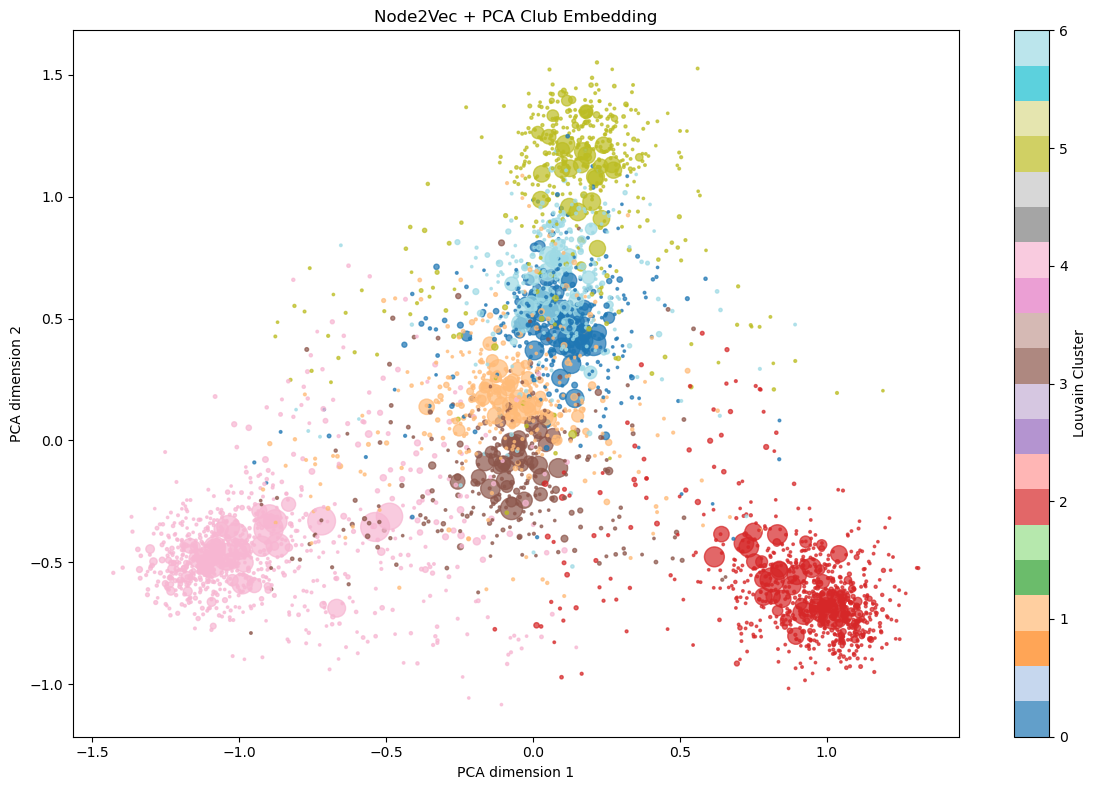

In [10]:
plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    club_embeddings["embed_x"],
    club_embeddings["embed_y"],
    c=club_embeddings["louvain_cluster"],
    s=club_embeddings["pagerank"] * 50000,
    alpha=0.7,
    cmap="tab20"
)

plt.colorbar(scatter, label="Louvain Cluster")
plt.title("Node2Vec + PCA Club Embedding")
plt.xlabel("PCA dimension 1")
plt.ylabel("PCA dimension 2")
plt.tight_layout()
plt.show()

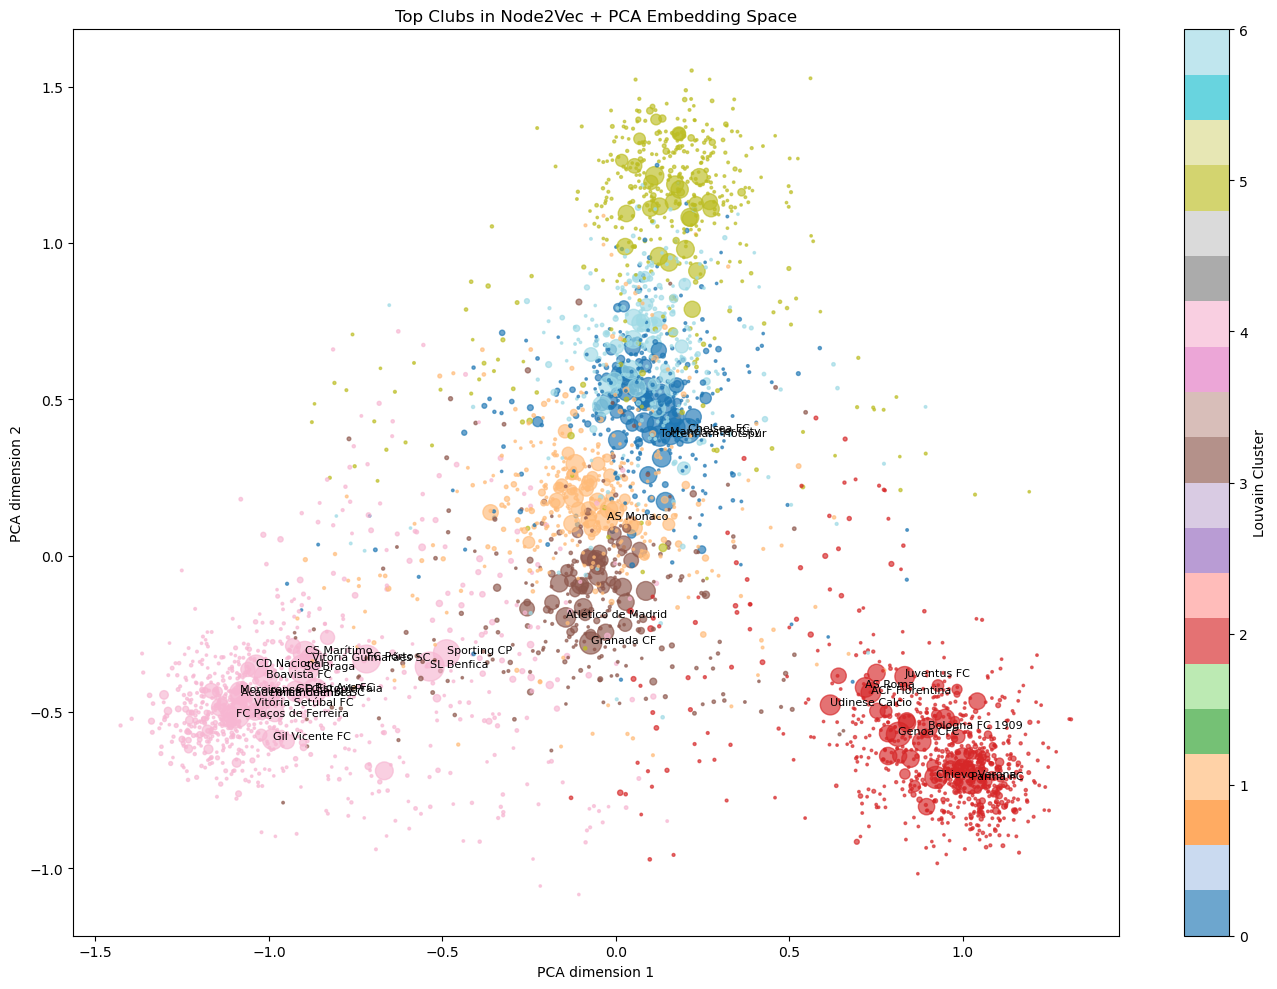

In [11]:
top_label_clubs = club_embeddings.sort_values("pagerank", ascending=False).head(30)

plt.figure(figsize=(14, 10))

scatter = plt.scatter(
    club_embeddings["embed_x"],
    club_embeddings["embed_y"],
    c=club_embeddings["louvain_cluster"],
    s=club_embeddings["pagerank"] * 50000,
    alpha=0.65,
    cmap="tab20"
)

plt.colorbar(scatter, label="Louvain Cluster")

for _, row in top_label_clubs.iterrows():
    plt.text(
        row["embed_x"],
        row["embed_y"],
        row["club"],
        fontsize=8
    )

plt.title("Top Clubs in Node2Vec + PCA Embedding Space")
plt.xlabel("PCA dimension 1")
plt.ylabel("PCA dimension 2")
plt.tight_layout()
plt.show()

In [14]:
louvain_summary = (
    club_embeddings
    .groupby("louvain_cluster")
    .agg(
        number_of_clubs=("club", "count"),
        average_pagerank=("pagerank", "mean"),
        average_degree=("degree", "mean"),
        average_weighted_degree=("weighted_degree", "mean")
    )
    .reset_index()
    .sort_values("number_of_clubs", ascending=False)
)

display(louvain_summary)

,louvain_cluster,number_of_clubs,average_pagerank,average_degree,average_weighted_degree
4,4,884,0.000260,12.664027,24.742081
2,2,826,0.000225,14.796610,36.778450
5,5,464,0.000235,13.635776,28.868534
1,1,427,0.000266,18.407494,36.494145
0,0,412,0.000383,25.941748,53.067961
3,3,297,0.000379,26.915825,59.063973
6,6,296,0.000308,21.141892,44.881757


In [15]:
for cluster_id in sorted(club_embeddings["louvain_cluster"].unique()):
    print(f"\nLouvain Cluster {cluster_id}")
    display(
        club_embeddings[
            club_embeddings["louvain_cluster"] == cluster_id
        ]
        .sort_values("pagerank", ascending=False)
        [
            [
                "club",
                "country",
                "pagerank",
                "degree",
                "weighted_degree",
                "transfers_in",
                "transfers_out"
            ]
        ]
        .head(10)
    )


Louvain Cluster 0


,club,country,pagerank,degree,weighted_degree,transfers_in,transfers_out
37,Chelsea FC,England,0.006258,340,1143,569.0,574.0
27,Manchester City,England,0.004848,308,896,433.0,463.0
5,Tottenham Hotspur,England,0.004334,238,723,359.0,364.0
83,Sunderland AFC,England,0.003893,248,611,307.0,304.0
55,West Ham United,England,0.003855,271,606,322.0,284.0
183,Crystal Palace,England,0.003837,220,466,248.0,218.0
25,Liverpool FC,England,0.003722,255,687,345.0,342.0
3,Newcastle United,England,0.003672,252,567,293.0,274.0
62,Aston Villa,England,0.003657,228,597,310.0,287.0
117,Stoke City,England,0.003640,217,509,267.0,242.0



Louvain Cluster 1


,club,country,pagerank,degree,weighted_degree,transfers_in,transfers_out
179,AS Monaco,France,0.005142,308,918,461.0,457.0
320,LOSC Lille,France,0.003847,234,595,295.0,300.0
246,Stade Rennais FC,France,0.003543,251,656,322.0,334.0
135,Olympique Marseille,France,0.003455,239,604,319.0,285.0
181,AS Saint-Étienne,France,0.003178,246,576,291.0,285.0
2,FC Girondins Bordeaux,France,0.002862,218,528,272.0,256.0
485,OGC Nice,France,0.002830,224,535,279.0,256.0
379,Montpellier HSC,France,0.002617,185,361,179.0,182.0
289,Paris Saint-Germain,France,0.002560,191,563,291.0,272.0
517,FC Metz,France,0.002444,174,313,166.0,147.0



Louvain Cluster 2


...

,club,country,pagerank,degree,weighted_degree,transfers_in,transfers_out
174,SC Braga,Portugal,0.008809,358,1116,567.0,549.0
129,SL Benfica,Portugal,0.008656,436,1285,637.0,648.0
262,FC Porto,Portugal,0.007986,347,1201,586.0,615.0
185,Sporting CP,Portugal,0.007218,424,1078,547.0,531.0
536,Vitória Setúbal FC,Portugal,0.007159,328,707,352.0,355.0
505,FC Paços de Ferreira,Portugal,0.006902,313,704,355.0,349.0
422,Rio Ave FC,Portugal,0.005762,274,732,378.0,354.0
217,Vitória Guimarães SC,Portugal,0.005687,314,749,376.0,373.0
456,CS Marítimo,Portugal,0.005671,290,572,291.0,281.0
595,Boavista FC,Portugal,0.005468,262,460,245.0,215.0



Louvain Cluster 5


,club,country,pagerank,degree,weighted_degree,transfers_in,transfers_out
428,ADO Den Haag,Netherlands,0.003467,223,527,268.0,259.0
394,SC Heerenveen,Netherlands,0.003289,234,534,263.0,271.0
327,Feyenoord Rotterdam,Netherlands,0.003257,190,564,289.0,275.0
283,Vitesse Arnhem,Netherlands,0.003189,206,525,262.0,263.0
209,Twente Enschede FC,Netherlands,0.003159,227,537,280.0,257.0
336,Willem II Tilburg,Netherlands,0.003098,187,494,267.0,227.0
451,FC Groningen,Netherlands,0.002963,210,478,239.0,239.0
299,FC Utrecht,Netherlands,0.002890,182,496,250.0,246.0
374,Fortuna Sittard,Netherlands,0.002817,168,251,134.0,117.0
225,PSV Eindhoven,Netherlands,0.002816,192,530,259.0,271.0



Louvain Cluster 6


,club,country,pagerank,degree,weighted_degree,transfers_in,transfers_out
284,TSG 1899 Hoffenheim,Germany,0.003791,261,662,331.0,331.0
291,VfL Wolfsburg,Germany,0.003778,242,643,333.0,310.0
293,FC Schalke 04,Germany,0.003437,215,621,313.0,308.0
550,1.FSV Mainz 05,Germany,0.003337,206,536,267.0,269.0
355,Eintracht Frankfurt,Germany,0.003326,231,552,299.0,253.0
172,Bayer 04 Leverkusen,Germany,0.003160,206,543,270.0,273.0
36,SV Werder Bremen,Germany,0.002926,224,523,269.0,254.0
458,FC Augsburg,Germany,0.002776,170,445,237.0,208.0
195,VfB Stuttgart,Germany,0.002768,189,471,235.0,236.0
347,SC Freiburg,Germany,0.002705,180,431,215.0,216.0


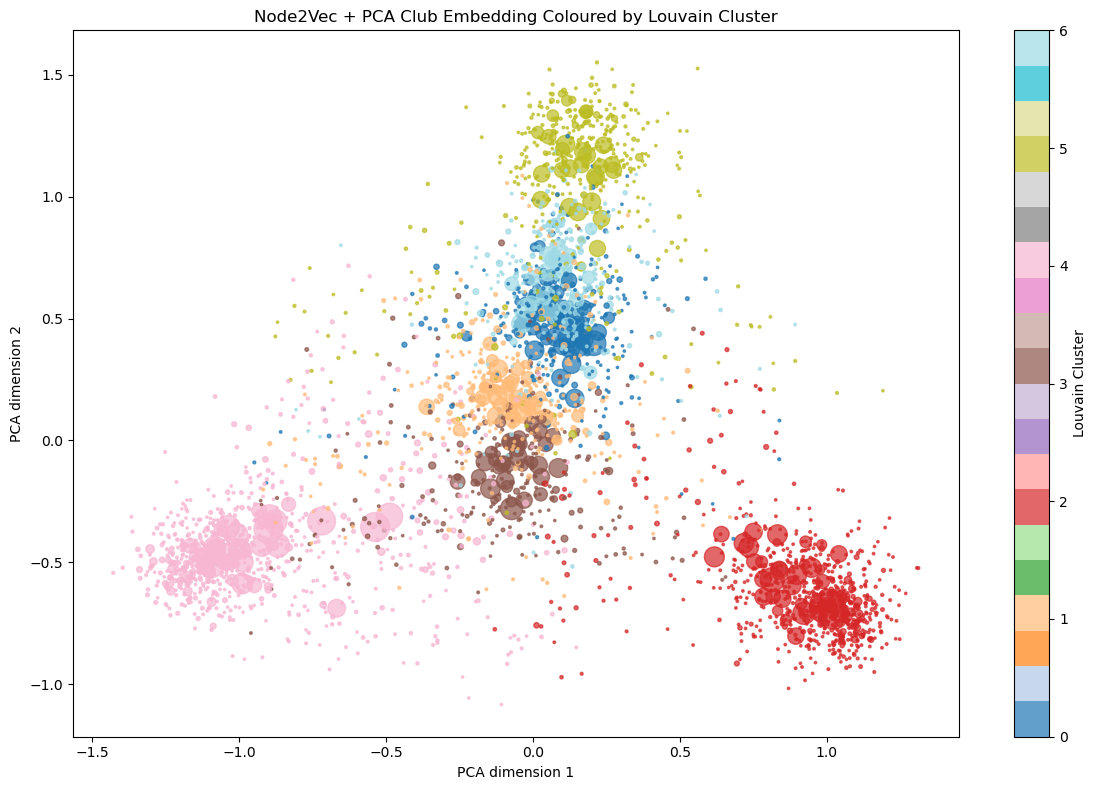

In [16]:
plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    club_embeddings["embed_x"],
    club_embeddings["embed_y"],
    c=club_embeddings["louvain_cluster"],
    s=club_embeddings["pagerank"] * 50000,
    alpha=0.7,
    cmap="tab20"
)

plt.colorbar(scatter, label="Louvain Cluster")
plt.title("Node2Vec + PCA Club Embedding Coloured by Louvain Cluster")
plt.xlabel("PCA dimension 1")
plt.ylabel("PCA dimension 2")
plt.tight_layout()
plt.show()

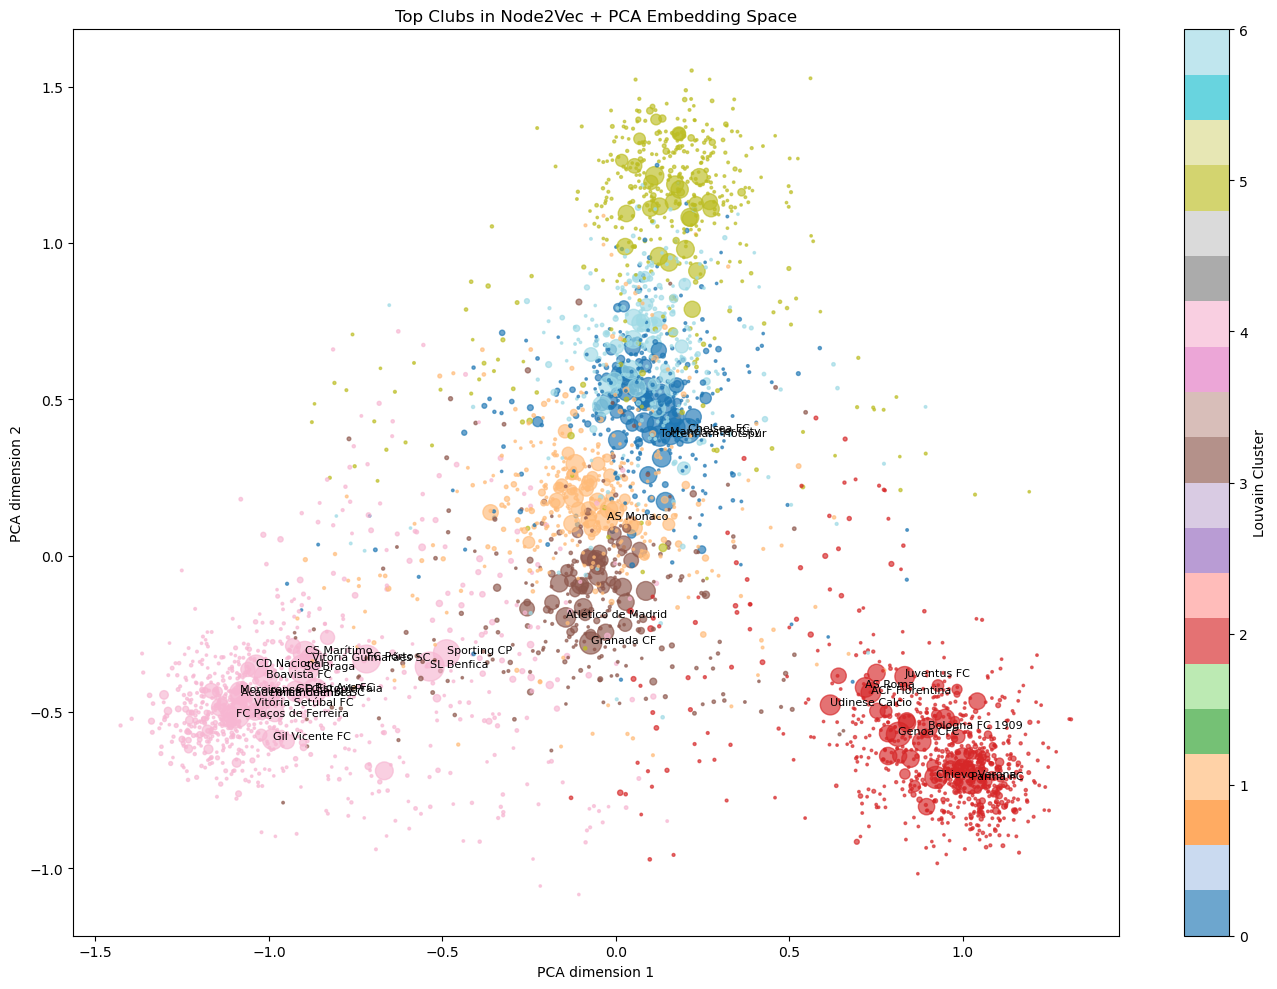

In [17]:
top_label_clubs = club_embeddings.sort_values("pagerank", ascending=False).head(30)

plt.figure(figsize=(14, 10))

scatter = plt.scatter(
    club_embeddings["embed_x"],
    club_embeddings["embed_y"],
    c=club_embeddings["louvain_cluster"],
    s=club_embeddings["pagerank"] * 50000,
    alpha=0.65,
    cmap="tab20"
)

plt.colorbar(scatter, label="Louvain Cluster")

for _, row in top_label_clubs.iterrows():
    plt.text(
        row["embed_x"],
        row["embed_y"],
        row["club"],
        fontsize=8
    )

plt.title("Top Clubs in Node2Vec + PCA Embedding Space")
plt.xlabel("PCA dimension 1")
plt.ylabel("PCA dimension 2")
plt.tight_layout()
plt.show()

In [18]:
club_embeddings.to_csv("club_embeddings.csv", index=False)
louvain_summary.to_csv("louvain_cluster_summary.csv", index=False)

print("Saved:")
print("club_embeddings.csv")
print("louvain_cluster_summary.csv")

Saved:
club_embeddings.csv
louvain_cluster_summary.csv
